# Air Quality & Heart Disease — Complete Data Mining Practical

**Files used**
- `air_quality_dataset.csv` — 500 records, 14 columns
- `synthetic_heart_disease_dataset.csv` — 50,000 records, 21 columns

## Operations performed
1. Data Cleaning
2. Data Integration
3. Data Transformation
4. Error Correction
5. Data Model Building

> This notebook is designed for **local Jupyter Notebook**. Keep both CSV files in the **same folder as this `.ipynb` file**.


## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the Exact Datasets

In [2]:
# Both CSV files should be in the same folder as this notebook.
air = pd.read_csv("air_quality_dataset.csv")
heart = pd.read_csv("synthetic_heart_disease_dataset.csv")

print("Air Quality Dataset Shape:", air.shape)
print("Heart Disease Dataset Shape:", heart.shape)

print("\nAir Quality Columns:")
print(air.columns.tolist())

print("\nHeart Disease Columns:")
print(heart.columns.tolist())


Air Quality Dataset Shape: (500, 14)
Heart Disease Dataset Shape: (50000, 21)

Air Quality Columns:
['PM2.5', 'PM10', 'NOx', 'NO2', 'SO2', 'VOCs', 'CO', 'CO2', 'CH4', 'Temperature', 'Humidity', 'Wind_Direction', 'Location_Type', 'Source_Label']

Heart Disease Columns:
['Age', 'Gender', 'Weight', 'Height', 'BMI', 'Smoking', 'Alcohol_Intake', 'Physical_Activity', 'Diet', 'Stress_Level', 'Hypertension', 'Diabetes', 'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Blood_Sugar_Fasting', 'Cholesterol_Total', 'Heart_Disease']


## 3. Initial Data Inspection

In [3]:
print("===== AIR QUALITY DATASET =====")
display(air.head())
print("\nData types:")
print(air.dtypes)
print("\nMissing values:")
print(air.isnull().sum())

print("\n===== HEART DISEASE DATASET =====")
display(heart.head())
print("\nData types:")
print(heart.dtypes)
print("\nMissing values:")
print(heart.isnull().sum())


===== AIR QUALITY DATASET =====


,PM2.5,PM10,NOx,NO2,SO2,VOCs,CO,CO2,CH4,Temperature,Humidity,Wind_Direction,Location_Type,Source_Label
0,39.967142,57.926035,116.192213,55.230299,4.531693,75.317261,2.789606,427.674347,1.706105,31.085120,45.454749,276,Urban,Vehicular
1,101.935672,150.774299,76.826826,79.051618,18.744780,145.083987,1.966569,529.739619,2.492663,33.711103,60.798212,134,Industrial,Industrial
2,70.996192,138.948796,158.731020,60.466604,14.892239,145.147338,2.626446,499.889443,2.431165,33.778698,54.875669,1,Industrial,Industrial
3,28.464728,63.643900,25.385343,15.333286,7.647429,130.022319,1.779360,388.283712,1.818563,31.565877,67.113319,251,Rural,Biomass Burning
4,78.265276,113.977926,105.644340,59.202337,17.696806,181.713667,3.240533,464.739197,2.597225,32.229835,37.236519,326,Industrial,Industrial



Data types:
PM2.5             float64
PM10              float64
NOx               float64
NO2               float64
SO2               float64
VOCs              float64
CO                float64
CO2               float64
CH4               float64
Temperature       float64
Humidity          float64
Wind_Direction      int64
Location_Type         str
Source_Label          str
dtype: object

Missing values:
PM2.5             0
PM10              0
NOx               0
NO2               0
SO2               0
VOCs              0
CO                0
CO2               0
CH4               0
Temperature       0
Humidity          0
Wind_Direction    0
Location_Type     0
Source_Label      0
dtype: int64

===== HEART DISEASE DATASET =====


,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,Hypertension,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,Male,78,157,26.4,Never,NaN,Sedentary,Healthy,Medium,0,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Low,Active,Average,High,1,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,NaN,Moderate,Average,Medium,0,0,0,1,0,116,102,78,148,208,0
3,75,Male,106,171,37.4,Never,Moderate,Moderate,Average,Low,0,0,1,0,0,171,92,109,105,290,1
4,34,Female,65,191,18.5,Current,NaN,Sedentary,Healthy,Low,1,1,0,0,0,164,67,108,116,220,1



Data types:
Age                        int64
Gender                       str
Weight                     int64
Height                     int64
BMI                      float64
Smoking                      str
Alcohol_Intake               str
Physical_Activity            str
Diet                         str
Stress_Level                 str
Hypertension               int64
Diabetes                   int64
Hyperlipidemia             int64
Family_History             int64
Previous_Heart_Attack      int64
Systolic_BP                int64
Diastolic_BP               int64
Heart_Rate                 int64
Blood_Sugar_Fasting        int64
Cholesterol_Total          int64
Heart_Disease              int64
dtype: object

Missing values:
Age                          0
Gender                       0
Weight                       0
Height                       0
BMI                          0
Smoking                      0
Alcohol_Intake           20109
Physical_Activity            0
Diet           

## 4. Data Cleaning — Remove Duplicate Records

In [4]:
air_before = len(air)
heart_before = len(heart)

air = air.drop_duplicates().reset_index(drop=True)
heart = heart.drop_duplicates().reset_index(drop=True)

print("Air Quality duplicates removed:", air_before - len(air))
print("Heart Disease duplicates removed:", heart_before - len(heart))

print("Air Quality shape after cleaning:", air.shape)
print("Heart Disease shape after cleaning:", heart.shape)


Air Quality duplicates removed: 0
Heart Disease duplicates removed: 0
Air Quality shape after cleaning: (500, 14)
Heart Disease shape after cleaning: (50000, 21)


## 5. Data Cleaning — Handle Missing Values

In [5]:
def fill_missing_values(df):
    df = df.copy()

    # Numerical columns -> median
    for col in df.select_dtypes(include=np.number).columns:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())

    # Categorical columns -> mode
    for col in df.select_dtypes(exclude=np.number).columns:
        if df[col].isnull().any():
            mode = df[col].mode()
            if not mode.empty:
                df[col] = df[col].fillna(mode.iloc[0])

    return df

air = fill_missing_values(air)
heart = fill_missing_values(heart)

print("Remaining Air Quality missing values:", air.isnull().sum().sum())
print("Remaining Heart Disease missing values:", heart.isnull().sum().sum())


Remaining Air Quality missing values: 0
Remaining Heart Disease missing values: 0


## 6. Error Correcting — Air Quality Dataset

In [6]:
# Air-quality measurements such as PM2.5, PM10, NOx, NO2, SO2, VOCs, CO,
# CO2 and CH4 should not contain negative values.

air_pollutants = [
    'PM2.5', 'PM10', 'NOx', 'NO2', 'SO2',
    'VOCs', 'CO', 'CO2', 'CH4'
]

error_report_air = {}

for col in air_pollutants:
    if col in air.columns:
        invalid = (air[col] < 0).sum()
        error_report_air[col] = int(invalid)

        if invalid > 0:
            air.loc[air[col] < 0, col] = np.nan
            air[col] = air[col].fillna(air[col].median())

print("Negative-value error report:")
display(pd.Series(error_report_air, name="Invalid Negative Values"))


Negative-value error report:


PM2.5    0
PM10     0
NOx      1
NO2      1
SO2      2
VOCs     0
CO       0
CO2      0
CH4      0
Name: Invalid Negative Values, dtype: int64

## 7. Error Correcting — Heart Disease Dataset

In [7]:
# Correct impossible negative values in health measurements.
heart_numeric_positive = [
    'Age', 'Weight', 'Height', 'BMI',
    'Systolic_BP', 'Diastolic_BP', 'Heart_Rate',
    'Blood_Sugar_Fasting', 'Cholesterol_Total'
]

error_report_heart = {}

for col in heart_numeric_positive:
    if col in heart.columns:
        invalid = (heart[col] < 0).sum()
        error_report_heart[col] = int(invalid)

        if invalid > 0:
            heart.loc[heart[col] < 0, col] = np.nan
            heart[col] = heart[col].fillna(heart[col].median())

print("Negative-value error report:")
display(pd.Series(error_report_heart, name="Invalid Negative Values"))


Negative-value error report:


Age                    0
Weight                 0
Height                 0
BMI                    0
Systolic_BP            0
Diastolic_BP           0
Heart_Rate             0
Blood_Sugar_Fasting    0
Cholesterol_Total      0
Name: Invalid Negative Values, dtype: int64

## 8. Error Checking — Range and Category Validation

In [8]:
# Check categorical values for consistency.
categorical_columns_air = ['Wind_Direction', 'Location_Type', 'Source_Label']
categorical_columns_heart = [
    'Gender', 'Smoking', 'Alcohol_Intake',
    'Physical_Activity', 'Diet', 'Stress_Level',
    'Hypertension', 'Diabetes', 'Hyperlipidemia',
    'Family_History', 'Previous_Heart_Attack'
]

print("Air Quality categorical values:")
for col in categorical_columns_air:
    if col in air.columns:
        print(f"\n{col}: {air[col].unique()}")

print("\nHeart Disease categorical values:")
for col in categorical_columns_heart:
    if col in heart.columns:
        print(f"\n{col}: {heart[col].unique()}")


Air Quality categorical values:

Wind_Direction: [276 134   1 251 326  61 206 186 230 159 171 143 337 303 112  98 103 141
 179 125  93 289 178  89 191 285 167 172 133  11 144  64 258 161 102 132
 335   0 291 311  85 235 111  34  41 308  96 183 345  50 290 140 193  86
 263 262 292 245  75 238 215 287 348 301 318 240 226 225 185  44 209 156
 180  63 213  76   8 296 158 227 349 119 324 293 113 278 101 297 169 241
 352 199 332 117 150 100 162  24 315  82 182  47 260 216 152 267  21 233
 253 197  30 304  42 231  88  31 153 212 247  38 280 316 261 176 343  71
  81 265 356 121   6 175 314  58 110 218 207 357 268  13 138 200 339 223
 194 330 320  60 208 155   9 256 187 322 205 174 246  46 321  73 277 347
  90 340 236 353 309 270 354 221  18 359  10 312 336 189 272  12  37 210
 115 302 196  43 220 228 255  84  70 147 355 164  15 181 333 242 136 219
  87 234 298 157 149 274 342 145  69 105 283 195  99 282 331  80 334  33
 154 202  91 232  48  22 120 288 107   4 323  68 299 177  66 129 300 146
 2

## 9. Data Transformation — Air Quality

In [9]:
# Convert categorical variables into numerical variables.
air_transformed = pd.get_dummies(
    air,
    columns=['Wind_Direction', 'Location_Type', 'Source_Label'],
    drop_first=True
)

# Standardize numerical air-quality attributes.
air_numeric = air_transformed.select_dtypes(include=np.number).columns

air_scaler = StandardScaler()
air_transformed[air_numeric] = air_scaler.fit_transform(
    air_transformed[air_numeric]
)

print("Air Quality data after transformation:")
display(air_transformed.head())
print("\nTransformed shape:", air_transformed.shape)


Air Quality data after transformation:


,PM2.5,PM10,NOx,NO2,SO2,VOCs,CO,CO2,CH4,Temperature,Humidity,Wind_Direction_1,Wind_Direction_4,Wind_Direction_6,Wind_Direction_7,Wind_Direction_8,Wind_Direction_9,Wind_Direction_10,Wind_Direction_11,Wind_Direction_12,Wind_Direction_13,Wind_Direction_15,Wind_Direction_17,Wind_Direction_18,Wind_Direction_21,Wind_Direction_22,Wind_Direction_24,Wind_Direction_26,Wind_Direction_28,Wind_Direction_30,Wind_Direction_31,Wind_Direction_33,Wind_Direction_34,Wind_Direction_35,Wind_Direction_37,Wind_Direction_38,Wind_Direction_40,Wind_Direction_41,Wind_Direction_42,Wind_Direction_43,Wind_Direction_44,Wind_Direction_46,Wind_Direction_47,Wind_Direction_48,Wind_Direction_50,Wind_Direction_51,Wind_Direction_52,Wind_Direction_58,Wind_Direction_60,Wind_Direction_61,Wind_Direction_63,Wind_Direction_64,Wind_Direction_65,Wind_Direction_66,Wind_Direction_68,Wind_Direction_69,Wind_Direction_70,Wind_Direction_71,Wind_Direction_73,Wind_Direction_75,Wind_Direction_76,Wind_Direction_78,Wind_Direction_80,Wind_Direction_81,Wind_Direction_82,Wind_Direction_84,Wind_Direction_85,Wind_Direction_86,Wind_Direction_87,Wind_Direction_88,Wind_Direction_89,Wind_Direction_90,Wind_Direction_91,Wind_Direction_93,Wind_Direction_95,Wind_Direction_96,Wind_Direction_98,Wind_Direction_99,Wind_Direction_100,Wind_Direction_101,Wind_Direction_102,Wind_Direction_103,Wind_Direction_105,Wind_Direction_107,Wind_Direction_110,Wind_Direction_111,Wind_Direction_112,Wind_Direction_113,Wind_Direction_115,Wind_Direction_117,Wind_Direction_119,Wind_Direction_120,Wind_Direction_121,Wind_Direction_125,Wind_Direction_129,Wind_Direction_132,Wind_Direction_133,Wind_Direction_134,Wind_Direction_136,Wind_Direction_137,Wind_Direction_138,Wind_Direction_140,Wind_Direction_141,Wind_Direction_143,Wind_Direction_144,Wind_Direction_145,Wind_Direction_146,Wind_Direction_147,Wind_Direction_148,Wind_Direction_149,Wind_Direction_150,Wind_Direction_152,Wind_Direction_153,Wind_Direction_154,Wind_Direction_155,Wind_Direction_156,Wind_Direction_157,Wind_Direction_158,Wind_Direction_159,Wind_Direction_160,Wind_Direction_161,Wind_Direction_162,Wind_Direction_164,Wind_Direction_165,Wind_Direction_167,Wind_Direction_168,Wind_Direction_169,Wind_Direction_171,Wind_Direction_172,Wind_Direction_174,Wind_Direction_175,Wind_Direction_176,Wind_Direction_177,Wind_Direction_178,Wind_Direction_179,Wind_Direction_180,Wind_Direction_181,Wind_Direction_182,Wind_Direction_183,Wind_Direction_185,Wind_Direction_186,Wind_Direction_187,Wind_Direction_189,Wind_Direction_191,Wind_Direction_193,Wind_Direction_194,Wind_Direction_195,Wind_Direction_196,Wind_Direction_197,Wind_Direction_198,Wind_Direction_199,Wind_Direction_200,Wind_Direction_201,Wind_Direction_202,Wind_Direction_205,Wind_Direction_206,Wind_Direction_207,Wind_Direction_208,Wind_Direction_209,Wind_Direction_210,Wind_Direction_211,Wind_Direction_212,Wind_Direction_213,Wind_Direction_215,Wind_Direction_216,Wind_Direction_218,Wind_Direction_219,Wind_Direction_220,Wind_Direction_221,Wind_Direction_222,Wind_Direction_223,Wind_Direction_224,Wind_Direction_225,Wind_Direction_226,Wind_Direction_227,Wind_Direction_228,Wind_Direction_229,Wind_Direction_230,Wind_Direction_231,Wind_Direction_232,Wind_Direction_233,Wind_Direction_234,Wind_Direction_235,Wind_Direction_236,Wind_Direction_238,Wind_Direction_239,Wind_Direction_240,Wind_Direction_241,Wind_Direction_242,Wind_Direction_245,Wind_Direction_246,Wind_Direction_247,Wind_Direction_251,Wind_Direction_252,Wind_Direction_253,Wind_Direction_254,Wind_Direction_255,Wind_Direction_256,Wind_Direction_257,Wind_Direction_258,Wind_Direction_260,Wind_Direction_261,Wind_Direction_262,Wind_Direction_263,Wind_Direction_264,Wind_Direction_265,Wind_Direction_267,Wind_Direction_268,Wind_Direction_269,Wind_Direction_270,Wind_Direction_272,Wind_Direction_274,Wind_Direction_276,Wind_Direction_277,Wind_Direction_278,Wind_Direction_280,Wind_Direction_282,Wind_Direction_283,Wind_Direction_285,Wind_Direction_287,Wind_Direction_288,Wind_Direction_289,Win


Transformed shape: (500, 281)


## 10. Data Transformation — Heart Disease

In [10]:
# Convert categorical columns to numerical dummy variables.
heart_transformed = pd.get_dummies(
    heart,
    columns=[
        'Gender', 'Smoking', 'Alcohol_Intake',
        'Physical_Activity', 'Diet', 'Stress_Level'
    ],
    drop_first=True
)

# Convert boolean dummy columns to integers.
bool_columns = heart_transformed.select_dtypes(include='bool').columns
heart_transformed[bool_columns] = heart_transformed[bool_columns].astype(int)

print("Heart Disease data after transformation:")
display(heart_transformed.head())
print("\nTransformed shape:", heart_transformed.shape)


Heart Disease data after transformation:


,Age,Weight,Height,BMI,Hypertension,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease,Gender_Male,Smoking_Former,Smoking_Never,Alcohol_Intake_Low,Alcohol_Intake_Moderate,Physical_Activity_Moderate,Physical_Activity_Sedentary,Diet_Healthy,Diet_Unhealthy,Stress_Level_Low,Stress_Level_Medium
0,48,78,157,26.4,0,0,1,1,0,104,99,71,165,200,0,1,0,1,1,0,0,1,1,0,0,1
1,35,73,163,33.0,1,0,1,1,0,111,72,60,145,206,0,0,0,1,1,0,0,0,0,0,0,0
2,79,88,152,32.3,0,0,0,1,0,116,102,78,148,208,0,0,0,1,1,0,1,0,0,0,0,1
3,75,106,171,37.4,0,0,1,0,0,171,92,109,105,290,1,1,0,1,0,1,1,0,0,0,1,0
4,34,65,191,18.5,1,1,0,0,0,164,67,108,116,220,1,0,0,0,1,0,0,1,1,0,1,0



Transformed shape: (50000, 26)


## 11. Data Integration

The two supplied datasets do **not** contain a common key such as Patient_ID, City, or Location that would allow a meaningful row-level merge.

Therefore, merging 500 air-quality rows with 50,000 patient rows directly would create artificial relationships and would be methodologically wrong.

Instead, we integrate their cleaned/transformed information into a common **dataset summary table**. This is the correct way to demonstrate integration when there is no valid common key.


In [11]:
integration_summary = pd.DataFrame({
    'Dataset': ['Air Quality', 'Heart Disease'],
    'Original_Rows': [500, 50000],
    'Cleaned_Rows': [len(air), len(heart)],
    'Columns': [air.shape[1], heart.shape[1]],
    'Numeric_Columns': [
        len(air.select_dtypes(include=np.number).columns),
        len(heart.select_dtypes(include=np.number).columns)
    ],
    'Categorical_Columns': [
        len(air.select_dtypes(exclude=np.number).columns),
        len(heart.select_dtypes(exclude=np.number).columns)
    ],
    'Missing_Values_After_Cleaning': [
        int(air.isnull().sum().sum()),
        int(heart.isnull().sum().sum())
    ]
})

display(integration_summary)

integration_summary.to_csv(
    "integrated_dataset_summary.csv",
    index=False
)

print("Integration summary saved as integrated_dataset_summary.csv")


,Dataset,Original_Rows,Cleaned_Rows,Columns,Numeric_Columns,Categorical_Columns,Missing_Values_After_Cleaning
0,Air Quality,500,500,14,12,2,0
1,Heart Disease,50000,50000,21,15,6,0


Integration summary saved as integrated_dataset_summary.csv


## 12. Optional Integrated Statistical View

In [12]:
# Create a single table containing important statistics from both datasets.
air_stats = air.describe().T
air_stats['Dataset'] = 'Air Quality'
air_stats['Feature'] = air_stats.index

heart_stats = heart.describe().T
heart_stats['Dataset'] = 'Heart Disease'
heart_stats['Feature'] = heart_stats.index

common_stats = pd.concat(
    [air_stats[['Dataset', 'Feature', 'mean', 'std', 'min', 'max']],
     heart_stats[['Dataset', 'Feature', 'mean', 'std', 'min', 'max']]],
    ignore_index=True
)

display(common_stats.head(20))


,Dataset,Feature,mean,std,min,max
0,Air Quality,PM2.5,54.671620,22.799473,10.757597,127.616632
1,Air Quality,PM10,84.703251,30.567912,12.932337,171.594187
2,Air Quality,NOx,92.005278,54.653744,3.509005,225.886935
3,Air Quality,NO2,42.493194,26.268991,0.838370,115.916428
4,Air Quality,SO2,11.542440,7.267972,1.241808,31.941860
5,Air Quality,VOCs,112.193098,39.471686,27.555617,231.926017
6,Air Quality,CO,2.177705,0.824762,0.366992,4.798935
7,Air Quality,CO2,439.288087,51.220578,366.063158,558.924257
8,Air Quality,CH4,2.130439,0.391396,1.388407,3.352266
9,Air Quality,Temperature,30.448413,2.957290,19.581349,39.778713


## 13. Build the Heart Disease Machine Learning Model

In [13]:
# Target variable in this exact dataset:
target = 'Heart_Disease'

X = heart_transformed.drop(columns=[target])
y = heart_transformed[target]

print("Target distribution:")
print(y.value_counts())
print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)


Target distribution:
Heart_Disease
0    26827
1    23173
Name: count, dtype: int64

Target percentage:
Heart_Disease
0    53.654
1    46.346
Name: proportion, dtype: float64


## 14. Train-Test Split and Feature Scaling

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of features:", X_train.shape[1])


Training samples: 40000
Testing samples: 10000
Number of features: 25


## 15. Data Model Building — Random Forest Classifier

In [15]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Model training completed.")


Model training completed.


## 16. Model Evaluation

Accuracy: 1.0000
Accuracy Percentage: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5365
           1       1.00      1.00      1.00      4635

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



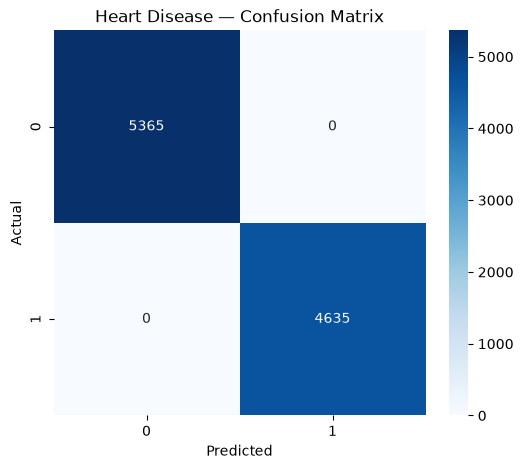

In [16]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Heart Disease — Confusion Matrix")
plt.show()


## 17. Feature Importance

Top 15 important features:


,Importance
Age,0.247475
Cholesterol_Total,0.244733
Hypertension,0.209327
Diabetes,0.148372
Previous_Heart_Attack,0.078861
BMI,0.008935
Blood_Sugar_Fasting,0.008405
Systolic_BP,0.008175
Weight,0.007903
Diastolic_BP,0.007773


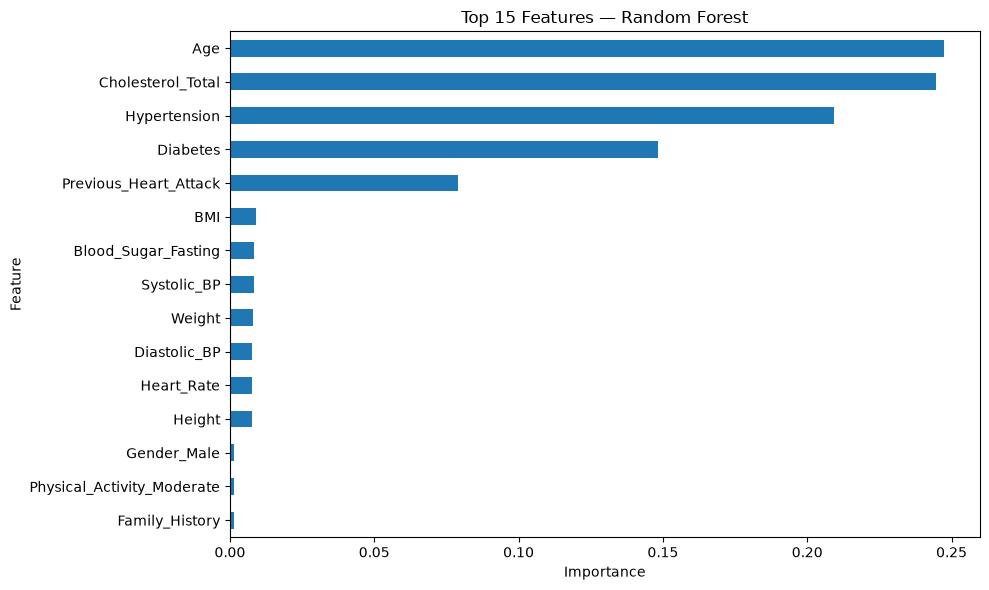

In [17]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 15 important features:")
display(feature_importance.head(15).to_frame("Importance"))

plt.figure(figsize=(10, 6))
feature_importance.head(15).sort_values().plot(kind='barh')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features — Random Forest")
plt.tight_layout()
plt.show()


## 18. Save Cleaned and Transformed Datasets

In [18]:
air.to_csv("air_quality_cleaned.csv", index=False)
heart.to_csv("heart_disease_cleaned.csv", index=False)

air_transformed.to_csv("air_quality_transformed.csv", index=False)
heart_transformed.to_csv("heart_disease_transformed.csv", index=False)

print("Files saved successfully:")
print("- air_quality_cleaned.csv")
print("- heart_disease_cleaned.csv")
print("- air_quality_transformed.csv")
print("- heart_disease_transformed.csv")
print("- integrated_dataset_summary.csv")


Files saved successfully:
- air_quality_cleaned.csv
- heart_disease_cleaned.csv
- air_quality_transformed.csv
- heart_disease_transformed.csv
- integrated_dataset_summary.csv


# Final Conclusion

### Data Cleaning
Removed duplicate records and handled missing values using median/mode methods.

### Data Integration
The two datasets were integrated at the analysis/summary level because they do not contain a valid common key. A direct row-wise merge would produce false relationships.

### Data Transformation
Categorical attributes were converted using one-hot encoding and numerical attributes were standardized.

### Error Correcting
Invalid negative values in measurements were identified and replaced using the median of the respective column.

### Data Model Building
A **Random Forest Classifier** was trained on the Heart Disease dataset to predict the `Heart_Disease` target.

### Model Evaluation
The model was evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Feature Importance
